# Analysis of thrombolysis and thrombectomy effects - all non-mild arrivals - mRS 0-2

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tabulate

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [2]:
all_data = pd.read_csv("../../data/sam3/cleaned_data.csv", low_memory=False)
treatment_results = pd.read_csv(
    "./output/01b_thrombolysis_thrombectomy_with_late_treatment_input.csv", low_memory=False)

# Limit data to 2023 onwards for more recent thrombectomy stats
all_data = all_data[all_data['year'] >= 2023]
treatment_results = treatment_results[treatment_results['year'] >= 2023]

# Add discharge_disability 0-2 to treatment_results
treatment_results['discharge_mrs_0_2'] = treatment_results['discharge_disability'] <= 2

## Use of thrombectomy in thrombectomy centres

In [3]:
centre_summary = (
    all_data.groupby(['thrombectomy_centre', 'year'])
            .agg(
                thrombectomy_mean_percent =('thrombectomy', 'mean'),
                thrombectomy_sum=('thrombectomy', 'sum'),
                thrombectomy_count=('thrombectomy', 'size'),
                arrival_to_thrombectomy_mean_percent=('arrival_to_thrombectomy_time', 'mean'),
                arrival_to_thrombectomy_median_percent=('arrival_to_thrombectomy_time', 'median'),
            )
)

centre_summary['thrombectomy_mean_percent'] = centre_summary['thrombectomy_mean_percent'] * 100


centre_summary[['thrombectomy_mean_percent', 'thrombectomy_sum', 'thrombectomy_count',
                'arrival_to_thrombectomy_mean_percent', 'arrival_to_thrombectomy_median_percent']].round(1)

# Split multi-index into columns
centre_summary = centre_summary.reset_index()

centre_summary

,thrombectomy_centre,year,thrombectomy_mean_percent,thrombectomy_sum,thrombectomy_count,arrival_to_thrombectomy_mean_percent,arrival_to_thrombectomy_median_percent
0,0.0,2023,3.033617,1692,55775,300.676714,239.0
1,0.0,2024,3.716006,2092,56297,308.964627,234.0
2,0.0,2025,4.083047,2297,56257,301.119721,227.0
3,1.0,2023,5.780574,1323,22887,177.393046,121.0
4,1.0,2024,6.149889,1363,22163,206.718269,139.0
5,1.0,2025,6.778972,1501,22142,261.347768,132.0


In [4]:
centre_summary = (
    all_data.groupby(['thrombectomy_centre'])
            .agg(
                thrombectomy_mean=('thrombectomy', 'mean'),
                thrombectomy_sum=('thrombectomy', 'sum'),
                thrombectomy_count=('thrombectomy', 'size'),
                arrival_to_thrombectomy_mean=('arrival_to_thrombectomy_time', 'mean'),
                arrival_to_thrombectomy_median=('arrival_to_thrombectomy_time', 'median'),
            )
)

centre_summary[['thrombectomy_mean', 'thrombectomy_sum', 'thrombectomy_count',
                'arrival_to_thrombectomy_mean', 'arrival_to_thrombectomy_median']] 

,thrombectomy_mean,thrombectomy_sum,thrombectomy_count,arrival_to_thrombectomy_mean,arrival_to_thrombectomy_median
thrombectomy_centre,,,,,
0.0,0.036126,6081,168329,303.695280,233.0
1.0,0.062314,4187,67192,217.036303,131.0


## Target trial emulation with k-nearest-neighbours matching

In [5]:
# Get treatment_results for thrombectomy centres only
thrombectomy_results_thrombectomy_centre = (
    treatment_results[(treatment_results['thrombectomy_centre'] == 1) &
                      (treatment_results['thrombectomy'] == 1)]
)
thrombectomy_results_ivt_centre = (
    treatment_results[(treatment_results['thrombectomy_centre'] == 0) &
                      (treatment_results['thrombectomy'] == 1)]
)

print(f'Number of thrombectomy results for thrombectomy centres: {len(thrombectomy_results_thrombectomy_centre)}')
print(f'Number of thrombectomy results for IVT centres: {len(thrombectomy_results_ivt_centre)}')

Number of thrombectomy results for thrombectomy centres: 3678
Number of thrombectomy results for IVT centres: 5426


In [6]:
fields_to_match = [
    'age',
    'stroke_severity',
    'prior_disability',
    'any_afib_diagnosis',
    'afib_anticoagulant',
    'onset_known',
    'early_arrival',
    'thrombolysis'
]

Matching function

In [7]:
def get_knn_matches(df_treated, df_untreated, match_columns, k=1):
    """
    Finds k nearest untreated patients for each treated patient based on 
    standardized columns, returning the original untreated dataframe rows.
    """
    
    # 1. Isolate the specific columns to match on
    treated_features = df_treated[match_columns]
    untreated_features = df_untreated[match_columns]
    
    # 2. Standardize the data
    # We fit the scaler on the untreated (control) pool to establish the baseline scale,
    # then transform both dataframes to that same scale.
    scaler = StandardScaler()
    scaler.fit(untreated_features)
    
    X_treated_scaled = scaler.transform(treated_features)
    X_untreated_scaled = scaler.transform(untreated_features)
    
    # 3. Fit Nearest Neighbors on the standardized untreated pool
    nn = NearestNeighbors(n_neighbors=k, algorithm='auto')
    nn.fit(X_untreated_scaled)
    
    # 4. Query the model to find the k nearest neighbors for each treated patient
    distances, indices = nn.kneighbors(X_treated_scaled)
    
    # 5. Extract the matched untreated patients using the original unscaled data
    # Flatten the 2D indices array to a 1D array so we can slice the dataframe
    matched_indices = indices.flatten()
    df_matched_controls = df_untreated.iloc[matched_indices].copy()
    
    # 6. (Optional but recommended) Add tracking columns
    # Track which treated patient index this control was matched to, and how far apart they were
    df_matched_controls['matched_to_treated_index'] = np.repeat(df_treated.index, k)
    df_matched_controls['knn_distance'] = distances.flatten()
    
    return df_matched_controls

In [8]:
matched_ivt = get_knn_matches(thrombectomy_results_thrombectomy_centre, 
                                thrombectomy_results_ivt_centre, fields_to_match, k=1)

In [9]:
matched_ivt

,stroke_team,age,male,ethnicity,onset_to_arrival_time,onset_known,precise_onset_known,onset_during_sleep,arrive_by_ambulance,call_to_ambulance_arrival_time,...,death,discharge_disability,needs_assistance_on_discharge,thrombectomy_centre,early_arrival,treatment_group,patient_id,discharge_mrs_0_2,matched_to_treated_index,knn_distance
33743,IQO,37.5,1.0,White,149.0,1,1,0,1.0,NaN,...,0.0,4.0,1.0,0.0,1,early_thrombolysis_late_thrombectomy,33743,False,34,0.164114
8864,HLE,77.5,0.0,White,110.0,1,0,0,1.0,40.0,...,0.0,2.0,0.0,0.0,1,early_both,8864,True,112,0.000000
77722,OWH,57.5,1.0,Other/NK,143.0,1,1,0,NaN,NaN,...,0.0,2.0,0.0,0.0,1,early_thrombolysis_late_thrombectomy,77722,True,133,0.000000
60428,OWH,62.5,0.0,White,45.0,1,1,0,NaN,NaN,...,0.0,1.0,0.0,0.0,1,early_both,60428,True,143,0.000000
67504,KTR,72.5,0.0,White,92.0,1,1,0,0.0,NaN,...,0.0,3.0,1.0,0.0,0,late_thrombectomy_only,67504,False,238,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
950,HSI,77.5,0.0,White,NaN,0,0,1,1.0,38.0,...,0.0,4.0,NaN,0.0,0,thrombectomy_only_unknown_time,950,False,150984,0.164114
15969,JVL,62.5,1.0,White,211.0,1,1,0,1.0,NaN,...,0.0,5.0,1.0,0.0,1,early_thrombolysis_late_thrombectomy,15969,False,151095,0.000000
104981,ORC,92.5,0.0,White,623.0,1,0,0,1.0,NaN,...,0.0,5.0,0.0,0.0,0,late_thrombectomy_only,104981,False,151110,0.000000
118635,RGD,87.5,0.0,White,870.0,1,0,0,0.0,NaN,...,0.0,2.0,NaN,0.0,0,late_thrombectomy_only,118635,True,151113,0.000000


In [10]:
matched_ivt['knn_distance'].describe()

count    3678.000000
mean        0.129412
std         0.279759
min         0.000000
25%         0.000000
50%         0.000000
75%         0.164114
max         3.367001
Name: knn_distance, dtype: float64

In [11]:
# Compare discharge disability for matched patient pairs
discharge_disability_df = pd.DataFrame({
    "IVT Centre": matched_ivt["discharge_disability"].reset_index(drop=True),
    "Thrombectomy Centre": (
        thrombectomy_results_thrombectomy_centre["discharge_disability"]
        .reset_index(drop=True)
    ),
})

assert len(discharge_disability_df["IVT Centre"]) == len(
    discharge_disability_df["Thrombectomy Centre"]
)

discharge_disability_df.describe().round(2)

,IVT Centre,Thrombectomy Centre
count,3678.00,3678.00
mean,3.26,3.08
std,1.66,1.73
min,0.00,0.00
25%,2.00,2.00
50%,3.00,3.00
75%,4.00,4.00
max,6.00,6.00


In [12]:
from scipy.stats import ttest_ind

ivt = discharge_disability_df["IVT Centre"].dropna()
thrombectomy = discharge_disability_df["Thrombectomy Centre"].dropna()

result = ttest_ind(ivt, thrombectomy, equal_var=False)

t_stat = result.statistic
p_value = result.pvalue
dof = result.df

print(f"t = {t_stat:.3f}, p = {p_value:.4g}, df = {dof:.1f}")

t = 4.587, p = 4.578e-06, df = 7344.6


In [13]:
from scipy.stats import chi2_contingency

# Reset indices to avoid duplicate label issues
ivt_data = matched_ivt['discharge_mrs_0_2'].reset_index(drop=True).astype(int)
thrombectomy_data = thrombectomy_results_thrombectomy_centre['discharge_mrs_0_2'].reset_index(drop=True).astype(int)

# Create contingency table: rows = group, columns = outcome
contingency_crosstab = pd.crosstab(
    pd.Series([0]*len(ivt_data) + [1]*len(thrombectomy_data), name='Group'),
    pd.Series(list(ivt_data) + list(thrombectomy_data), name='Outcome')
)

chi2, p_value, dof, expected = chi2_contingency(contingency_crosstab)

print(f"Chi-squared test: chi2 = {chi2:.3f}, p = {p_value:.4g}, df = {dof}")
print("\nContingency Table:")
print(contingency_crosstab)


Chi-squared test: chi2 = 22.847, p = 1.755e-06, df = 1

Contingency Table:
Outcome     0     1
Group              
0        2446  1232
1        2248  1430


In [14]:
fields_to_describe = [
    'age',
    'stroke_severity',
    'prior_disability',
    'any_afib_diagnosis',
    'afib_anticoagulant',
    'onset_known',
    'early_arrival',
    'thrombolysis',
    'arrival_to_thrombolysis_time',
    'arrival_to_thrombectomy_time',
    'discharge_disability',
    'discharge_mrs_0_2'
]

descriptive_stats = pd.concat(
    [
        matched_ivt[fields_to_describe].describe().T,
        thrombectomy_results_thrombectomy_centre[fields_to_describe].describe().T,
    ],
    axis=1,
    keys=["IVT Centre", "Thrombectomy Centre"]
)

descriptive_stats.round(2).T

age  stroke_severity  prior_disability  \
IVT Centre          count  3678.00          3678.00           3678.00   
                    mean     70.52            16.10              0.64   
                    std      13.61             6.09              0.85   
                    min      37.50             1.00              0.00   
                    25%      62.50            11.00              0.00   
                    50%      72.50            16.00              0.00   
                    75%      82.50            21.00              1.00   
                    max      92.50            42.00              5.00   
Thrombectomy Centre count  3678.00          3678.00           3678.00   
                    mean     70.31            16.13              0.64   
                    std      13.88             6.28              0.87   
                    min      37.50             0.00              0.00   
                    25%      62.50            11.00              0.00   
                    50%      72.50            16.00              0.00   
                    75%      82.50            21.00              1.00   
                    max      92.50            40.00              5.00   

                           any_afib_diagnosis  afib_anticoagulant  \
IVT Centre          count             3678.00              3678.0   
                    mean                 0.34                 0.2   
                    std                  0.47                 0.4   
                    min                  0.00                 0.0   
                    25%                  0.00                 0.0   
                    50%                  0.00                 0.0   
                    75%                  1.00                 0.0   
                    max                  1.00                 1.0   
Thrombectomy Centre count             3678.00              3678.0   
                    mean                 0.34                 0.2   
                    std                  0.47                 0.4   
                    min                  0.00                 0.0   
                    25%                  0.00                 0.0   
                    50%                  0.00                 0.0   
                    75%                  1.00                 0.0   
                    max                  1.00                 1.0   

                           onset_known  early_arrival  thrombolysis  \
IVT Centre          count      3678.00        3678.00       3678.00   
                    mean          0.90           0.44          0.44   
                    std           0.31           0.50          0.50   
                    min           0.00           0.00          0.00   
                    25%           1.00           0.00          0.00   
                    50%           1.00           0.00          0.00   
                    75%           1.00           1.00          1.00   
                    max           1.00           1.00          1.00   
Thrombectomy Centre count      3678.00        3678.00       3678.00   
                    mean          0.90           0.44          0.44   
                    std           0.31           0.50          0.50   
                    min           0.00           0.00          0.00   
                    25%           1.00           0.00          0.00   
                    50%           1.00           0.00          0.00   
                    75%           1.00           1.00          1.00   
                    max           1.00           1.00          1.00   

                           arrival_to_thrombolysis_time  \
IVT Centre          count                       1627.00   
                    mean                          56.46   
                    std                           35.67   
                    min                           10.00   
                    25%                           36.00   
                    50%                           49.

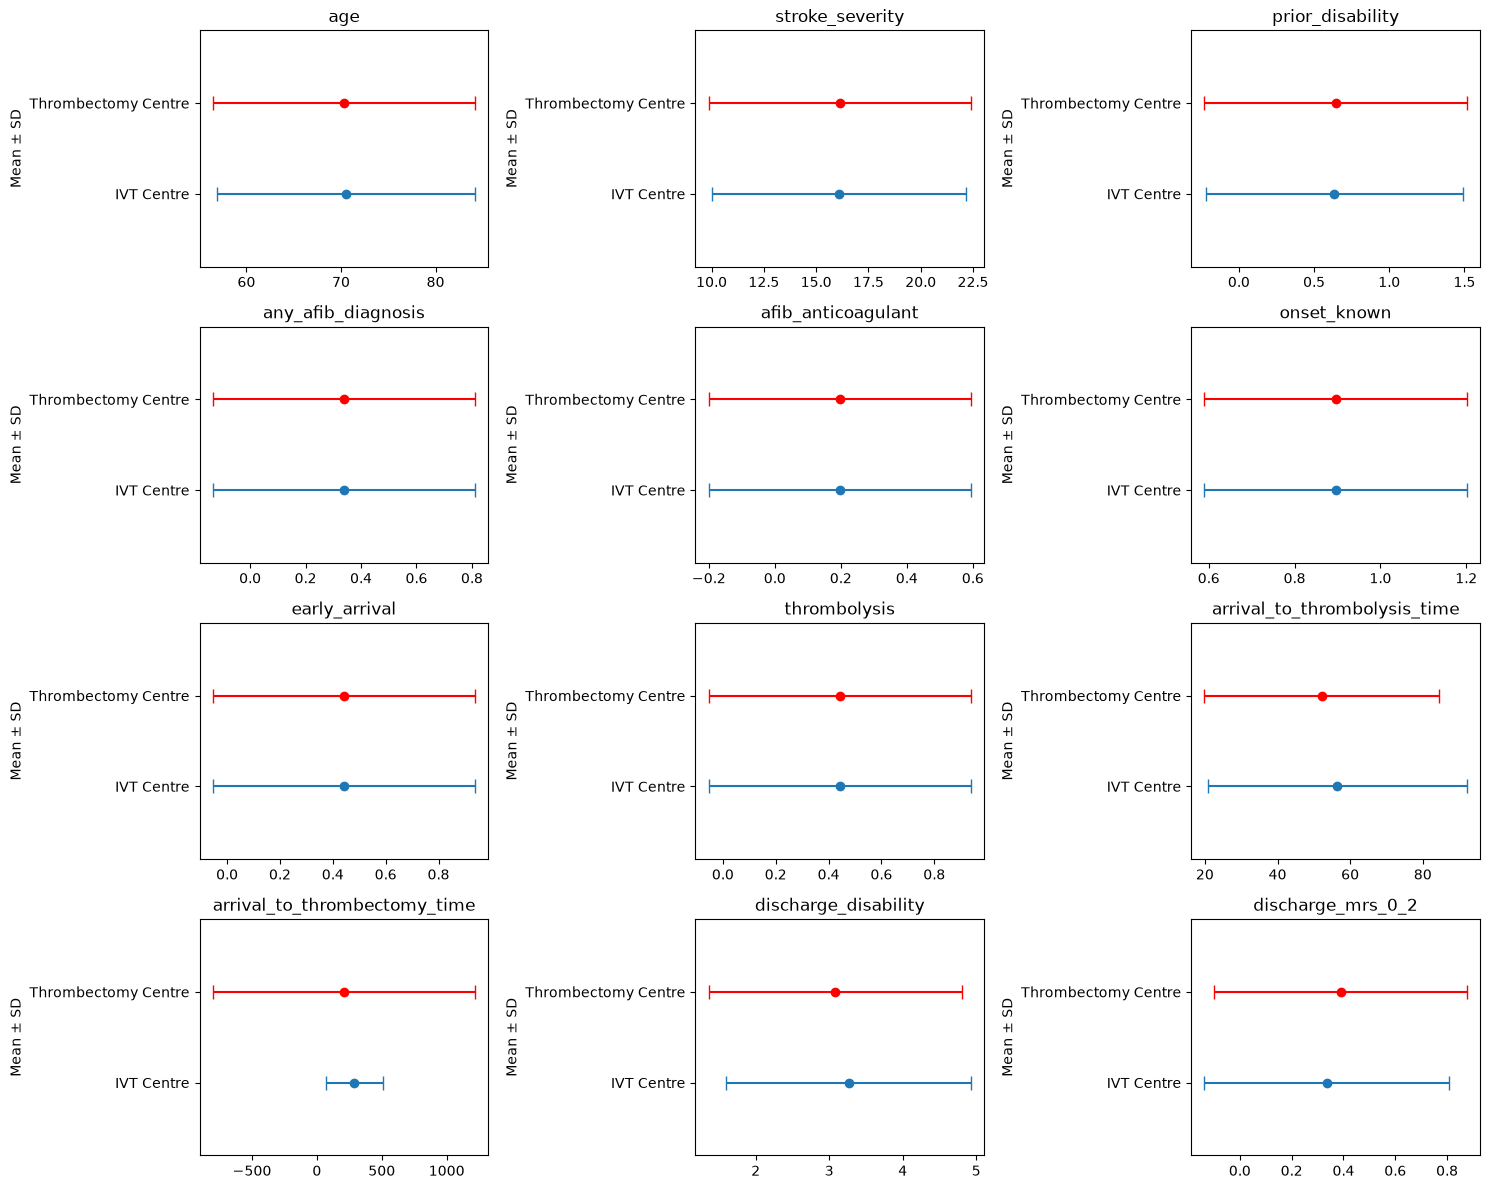

In [15]:
# Plot results for each feature in fields_to_describe as comparisons. Plot as a mean and standard deviation bar chart for each feature, with IVT Centre and Thrombectomy Centre side by side. Use subplots in a single figure.

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))

for i, field in enumerate(fields_to_describe):
    ax = axes.flat[i]
    ivt_data = matched_ivt[field].dropna()
    thrombectomy_data = thrombectomy_results_thrombectomy_centre[field].dropna()

    means = [ivt_data.mean(), thrombectomy_data.mean()]
    stds = [ivt_data.std(), thrombectomy_data.std()]

    labels = ["IVT Centre", "Thrombectomy Centre"]
    y_pos = np.arange(len(labels))

    ax.errorbar(means[0], y_pos[0], xerr=stds[0], fmt="o",
                color="tab:blue", capsize=5)
    ax.errorbar(means[1], y_pos[1], xerr=stds[1], fmt="o",
                color="red", capsize=5)

    ax.set_yticks(y_pos, labels)
    ax.set_ylim(-0.8, 1.8)
    ax.set_title(field)
    ax.set_ylabel("Mean ± SD")

# Hide unused subplots
for ax in axes.flat[len(fields_to_describe):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [16]:
headers = [
    "Feature",
    "IVT Mean", "IVT Std",
    "Thrombectomy Mean", "Thrombectomy Std",
]

table_rows = []

for field in fields_to_describe:
    ivt_data = matched_ivt[field].dropna()
    thrombectomy_data = thrombectomy_results_thrombectomy_centre[field].dropna()

    table_rows.append([
        field,
        f"{ivt_data.mean():.2f}",
        f"{ivt_data.std():.2f}",
        f"{thrombectomy_data.mean():.2f}",
        f"{thrombectomy_data.std():.2f}",
    ])

table = tabulate.tabulate(
    table_rows,
    headers=headers,
    tablefmt="grid",
)

print(table)


+------------------------------+------------+-----------+---------------------+--------------------+
| Feature                      |   IVT Mean |   IVT Std |   Thrombectomy Mean |   Thrombectomy Std |
+==============================+============+===========+=====================+====================+
| age                          |      70.52 |     13.61 |               70.31 |              13.88 |
+------------------------------+------------+-----------+---------------------+--------------------+
| stroke_severity              |      16.1  |      6.09 |               16.13 |               6.28 |
+------------------------------+------------+-----------+---------------------+--------------------+
| prior_disability             |       0.64 |      0.85 |                0.64 |               0.87 |
+------------------------------+------------+-----------+---------------------+--------------------+
| any_afib_diagnosis           |       0.34 |      0.47 |                0.34 |            

In [17]:
# Convert table to a pandas DataFrame for easier manipulation and saving
table_df = pd.DataFrame(table_rows, columns=headers)
table_df

,Feature,IVT Mean,IVT Std,Thrombectomy Mean,Thrombectomy Std
0,age,70.52,13.61,70.31,13.88
1,stroke_severity,16.10,6.09,16.13,6.28
2,prior_disability,0.64,0.85,0.64,0.87
3,any_afib_diagnosis,0.34,0.47,0.34,0.47
4,afib_anticoagulant,0.20,0.40,0.20,0.40
5,onset_known,0.90,0.31,0.90,0.31
6,early_arrival,0.44,0.50,0.44,0.50
7,thrombolysis,0.44,0.50,0.44,0.50
8,arrival_to_thrombolysis_time,56.46,35.67,52.22,32.36
9,arrival_to_thrombectomy_time,288.78,219.13,208.54,1011.02
